# Benchmarks: LINERLIB

Data Source: https://github.com/blof/LINERLIB

In [1]:
import cma
from cma import ServiceGraph, create_service_line
import test_benchmarks_utils as benchutils
from test_benchmarks_utils import \
	read_vessel_class_data, \
	read_port_data, \
	read_demand

## (1) Load Data

In [2]:
_, cma_portpool = cma.read_port_data()
vessel_pool = read_vessel_class_data()
portpool = read_port_data(vessel_pool, cma_portpool)
display(vessel_pool.numbers_list)
display(vessel_pool)

[np.int64(12), np.int64(24), np.int64(22), np.int64(42), 0, 0]

     Vessel Type  Vessel Number
0  Rank 1 Vessel             12
1  Rank 2 Vessel             24
2  Rank 3 Vessel             22
3  Rank 4 Vessel             42
4  Rank 5 Vessel              0
5  Rank 6 Vessel              0

435

In Total  127  ports are plotted


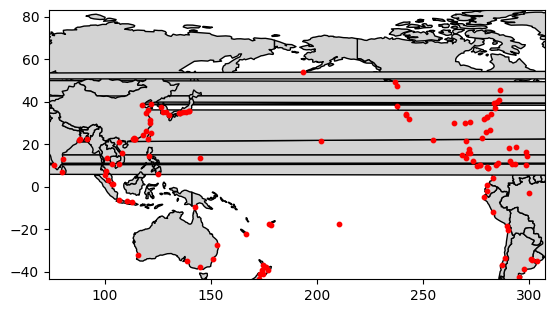

In [3]:
pacific = [
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore',
	'Brunei', 'Timor-Leste',
	'China', 'Japan', 'South Korea', 'North Korea',
	'Canada', 'Mexico',
	'Fiji', 'Australia'
]
display(portpool.get_number_of_ports())
_, _, portpool_Pacific = portpool.plot(pacific, center_pacific=True)

In [4]:
# create a new pool of ports with richer information
week_demands, unit_revenue = read_demand(portpool_Pacific)
dist_mat = cma.read_sailing_distance_data(portpool_Pacific)
portgraph = cma.PortGraph(portpool_Pacific, dist_mat, week_demands, unit_revenue)
num_ports = portgraph.get_number_of_ports()
print(f'In total {num_ports} ports have freight demand')
print(f'In total {len(portgraph.filtered_by_transship_capacity())} ports can transship')

In total 45 ports have freight demand
In total 45 ports can transship


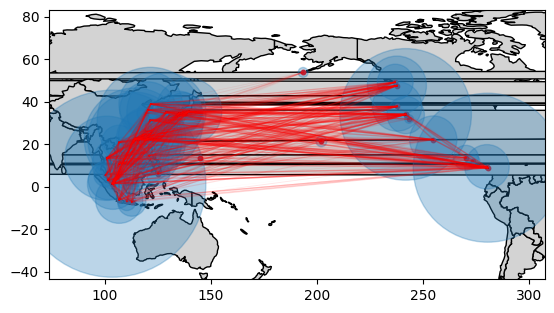

In [5]:
# plot the demands between ports
_, ax, _ = portgraph.plot(pacific, center_pacific=True)

## (2) Creating Initial Network

In [6]:
line_1 = create_service_line('line 1', benchutils.line_1_idlst, portpool)
line_2 = create_service_line('line 2', benchutils.line_2_idlst, portpool)
line_3 = create_service_line('line 3', benchutils.line_3_idlst, portpool)
line_4 = create_service_line('line 4', benchutils.line_4_idlst, portpool)
line_5 = create_service_line('line 5', benchutils.line_5_idlst, portpool)
line_6 = create_service_line('line 6', benchutils.line_6_idlst, portpool)
line_7 = create_service_line('line 7', benchutils.line_7_idlst, portpool)
line_8 = create_service_line('line 8', benchutils.line_8_idlst, portpool)
line_9 = create_service_line('line 9', benchutils.line_9_idlst, portpool)
line_10 = create_service_line('line 10', benchutils.line_10_idlst, portpool)
line_11 = create_service_line('line 11', benchutils.line_11_idlst, portpool)
line_12 = create_service_line('line 12', benchutils.line_12_idlst, portpool)
line_13 = create_service_line('line 13', benchutils.line_13_idlst, portpool)
line_14 = create_service_line('line 14', benchutils.line_14_idlst, portpool)
line_15 = create_service_line('line 15', benchutils.line_15_idlst, portpool)
line_16 = create_service_line('line 16', benchutils.line_16_idlst, portpool)
line_17 = create_service_line('line 17', benchutils.line_17_idlst, portpool)

init_service_lines = [line_1, line_2, line_3, line_4, line_5, line_6, line_7, line_8, line_9,
	line_10, line_11, line_12, line_13, line_14, line_15, line_16, line_17]
init_service_graph = ServiceGraph(init_service_lines)

In [7]:
# create a week prediction model
week_predictor = cma.create_week_predictor()
week_predictor.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:               OLS              Adj. R-squared:     0.890   
Dependent Variable:  weeks            AIC:                92.3843 
Date:                2025-08-15 22:23 BIC:                103.7352
No. Observations:    49               Log-Likelihood:     -40.192 
Df Model:            5                F-statistic:        78.32   
Df Residuals:        43               Prob (F-statistic): 1.77e-20
R-squared:           0.901            Scale:              0.34412 
------------------------------------------------------------------
                     Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
------------------------------------------------------------------
const               -0.5318   0.4189 -1.2695 0.2111 -1.3767 0.3130
sailing_distance     0.0005   0.0000 13.8420 0.0000  0.0004 0.0005
stops_number         0.0549   0.0379  1.4485 0.1547 -0.0215 0.1313
ave_productivity     0.0009   0.0022  0.4213 0.6757 -0.0035 0.0053
ave_demand_inflows   0.0002   0.0001  1.7211 0.0924 -0.0000 0.0005
ave_demand_outflows  0.0001   0.0002  0.5632 0.5763 -0.0003 0.0006
------------------------------------------------------------------
Omnibus:               8.717        Durbin-Watson:           1.521
Prob(Omnibus):         0.013        Jarque-Bera (JB):        7.882
Skew:                  0.909        Prob(JB):                0.019
Kurtosis:              3.743        Condition No.:           33496
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [8]:
# solve the optimal demand fulfillment
sol = init_service_graph.solve_approximated(
		portgraph, vessel_pool, week_predictor, min_cost=False)
init_service_graph.total_profit()

/Users/linsheng/Documents/GitHub/nus_cma_project/.venv/lib/python3.13/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


Set parameter Username
Set parameter LicenseID to value 2695823
Academic license - for non-commercial use only - expires 2026-08-15


np.float64(5593774.342063498)

## (3) Compare with Benchmark

### Benchmark Objective: 2.79196e+06
```
>>> Revenue               = 4.55798e+07
>>> Penalty               = 1.896e+06
>>> Bunkering cost        = 1.1363e+07
>>> Bunker idle burn cost = 268980
>>> Canal costs           = 230400
>>> Handling cost         = 1.80658e+07
```

In [9]:
print('>>> revenue            =', sol['revenue'].value)
print('>>> penalty            =', sol['penalty'].value)
print('>>> bunkering cost     =', sol['bunkering cost'].value)
print('>>> transshipment cost =', sol['transshipment cost'].value)
print('>>> chartering cost    =', sol['chartering cost'].value)
print('>>> portcall cost      =', sol['portcall cost'].value)

>>> revenue            = 45560079.603174604
>>> penalty            = 1787896.825396825
>>> bunkering cost     = 13830300.0
>>> transshipment cost = 13776915.261904761
>>> chartering cost    = 9317000.0
>>> portcall cost      = 1254193.1738095237


### Benchmark Weeks:
```
= [7, 13, 9, 3, 13, 7, 8, 4, 2, 2, 4, 10, 1.5, 5, 4, 6, 1]
```

In [10]:
print('Line Name\t', 'distance\t',
		'week\t', 'ships', '\t\t\t', 'capacities\t', 'speed')
idx_line = 0
for line, week, line_ships, line_cap in \
		zip(init_service_lines, sol['weeks'], sol['ships'], sol['capacities']):
	line_ships_val = [int(ship.value) for ship in line_ships]
	line_speeds = sol['speeds']
	print(
		line.name(), ' \t',
		int(line.get_distance(portgraph)), '\t\t',
		week, '\t',
		line_ships_val[:4], '   \t',
		line_cap.value, '   \t',
		line_speeds[idx_line])
	idx_line += 1

Line Name	 distance	 week	 ships 			 capacities	 speed
line 1  	 9688 		 6.0 	 [0, 0, 1, 2]    	 6000.0    	 10.10797124845721
line 2  	 30411 		 12.0 	 [0, 0, 0, 7]    	 16800.0    	 15.655185693525608
line 3  	 21903 		 9.0 	 [0, 17, 11, 0]    	 26800.0    	 15.160948053817272
line 4  	 5723 		 3.0 	 [0, 0, 1, 2]    	 6000.0    	 12.241994620040673
line 5  	 30581 		 12.0 	 [0, 0, 3, 15]    	 39600.0    	 16.215602170429374
line 6  	 13466 		 7.0 	 [0, 0, 0, 6]    	 14400.0    	 11.917246400629933
line 7  	 16129 		 9.0 	 [0, 0, 2, 2]    	 7200.0    	 11.063761792473066
line 8  	 5708 		 3.0 	 [1, 1, 0, 0]    	 1250.0    	 11.613346534610839
line 9  	 3395 		 2.0 	 [0, 0, 1, 0]    	 1200.0    	 10.581085303907846
line 10  	 4034 		 2.0 	 [0, 1, 0, 3]    	 8000.0    	 14.245852714274962
line 11  	 13594 		 7.0 	 [0, 2, 1, 0]    	 2800.0    	 11.650877370541018
line 12  	 18840 		 9.0 	 [0, 2, 0, 0]    	 1600.0    	 12.516728214088312
line 13  	 2581 		 1.0 	 [1, 0, 0, 0]    	 450.0   

In [11]:
demand_routes = sol['demand routes']
trans_ports = portgraph.filtered_by_transship_capacity()
print(len(trans_ports))
od_pairs_dict = init_service_graph.get_all_paths(portgraph, trans_ports)
od_pairs = od_pairs_dict['od_pairs']
od_pairs_paths = od_pairs_dict['od_pairs_path']
od_pairs_demand = od_pairs_dict['od_pairs_demand']
total_demand_rev = 0
realized_rev = 0

for x_od, od in zip(demand_routes, od_pairs):
	unit_rev = portgraph.get_unit_revenue_by_idx(*od)
	od_demand = portgraph.get_demand_by_idx(*od)
	accepted_demand = 0
	for x_od_p in x_od:
		accepted_demand += x_od_p.value
	total_demand_rev += od_demand * unit_rev
	realized_rev += accepted_demand * unit_rev
	print('from', od[0], 'to', od[1],
		' demand =', od_demand,
		' unit_prize = ', unit_rev,
		' fulfilled =', accepted_demand)

print('total demand revenue =', total_demand_rev)
print('realized revenue =', realized_rev, '(', 100 * realized_rev / total_demand_rev, '%)')

45
from 44 to 27  demand = 403.0  unit_prize =  810.0  fulfilled = 403.0
from 44 to 24  demand = 283.0  unit_prize =  1450.0  fulfilled = 283.0
from 44 to 11  demand = 267.0  unit_prize =  1330.0  fulfilled = 267.0
from 42 to 27  demand = 1066.0  unit_prize =  550.0  fulfilled = 1066.0
from 42 to 24  demand = 444.0  unit_prize =  1670.0  fulfilled = 444.0
from 42 to 11  demand = 673.0  unit_prize =  1590.0  fulfilled = 673.0
from 38 to 24  demand = 270.0  unit_prize =  1170.0  fulfilled = 270.0
from 35 to 11  demand = 296.0  unit_prize =  1450.0  fulfilled = 296.0
from 30 to 27  demand = 866.0  unit_prize =  410.0  fulfilled = 866.0
from 30 to 40  demand = 272.0  unit_prize =  1330.0  fulfilled = 272.0
from 30 to 11  demand = 369.0  unit_prize =  1440.0  fulfilled = 0.0
from 29 to 27  demand = 1739.0  unit_prize =  530.0  fulfilled = 1739.0
from 29 to 24  demand = 857.0  unit_prize =  1660.0  fulfilled = 857.0
from 29 to 11  demand = 823.0  unit_prize =  1610.0  fulfilled = 823.0
from 

## (4) Search for a Better Network (MCTS)

In [12]:
tree = cma.MonteCarloTree(servicegraph=init_service_graph,
	portgraph=portgraph, vesselpool=vessel_pool,
	discount_fac=0.5,  # control the simulation deepth
	c_param=0.5,       # balance exploration and exploitation
	max_depth=20,      # how many steps of adjustments are allowed
	min_cost=False,
	week_predict_model=week_predictor)

Run the following cell. Reexcute the cell if there is error. 

In [14]:
import time
from IPython.display import clear_output

run_time_seconds = 20 * 60   # 20 minutes
start_time = time.time()

while True:
	if time.time() - start_time >= run_time_seconds:
		print('Run time finished')
		break
	tree.run(10, True)
	clear_output(wait=False)
	print(tree.recorder())
	print('-----------------')
	tree.display_best_node(portgraph)

{'num_expand': 5, 'num_rollout': 5}
-----------------
Best Action Trace:
Action 1:
    For the #11 line "line 12 -- [MXESE, HKHKG, CNSHA, KRPUS, USOAK, SVAQJ, PABLB]",
    Add Port "PHMNL" in the segment (MXESE, HKHKG).
Siblings = 2
N visits = 7
Original profit = 5593774.342063498
Updated profit  = 5592903.347619064

Action 2:
    For the #1 line "line 2 -- [SGSIN, CNFOC, CNTAO, CNDLC, CAVAN, USSEA, CNXMN, KRPUS, USOAK, MXLZC, USLAX, HKHKG, CNYTN, MYTPP]",
    Add Port "JPHKT" in the segment (KRPUS, USOAK).
Siblings = 4
N visits = 1
Original profit = 5592903.347619064
Updated profit  = 5668229.290476194

Run time finished
